# 03 — Analyse des résultats (notebook de rapport PFE)

Cette notebook regroupe **toutes les figures défensables** du projet :

1. Pipeline & données — répartition des labels, exemples de signaux par groupe.
2. Marqueur appris — trajectoire de la puissance alpha au fil des séances.
3. Performance du modèle — validation croisée patient-wise (5 folds).
4. Diagnostic du modèle — courbe ROC, matrice de confusion, distribution des probabilités.
5. Importance des features — corrélation feature ↔ label.

Toutes les métriques rapportées proviennent de la **validation croisée patient-wise**, donc sans fuite d'information.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.signal import welch
from sklearn.metrics import confusion_matrix, roc_curve

from src.data.loader import load
from src.preprocessing.pipeline import PipelineConfig, preprocess
from src.models.lstm import LSTMConfig
from src.models.train import TrainConfig, cross_validate

ds = load(ROOT / "data" / "simulated")
pre = preprocess(ds.signals, PipelineConfig(fs=ds.fs, mode="features"))
X = pre.x; y = ds.labels.astype(np.float32); groups = np.arange(X.shape[0])
print("X:", X.shape, "y balance:", int(y.sum()), "/", len(y))

X: (100, 10, 8) y balance: 50 / 100


## 1. Données & marqueur appris

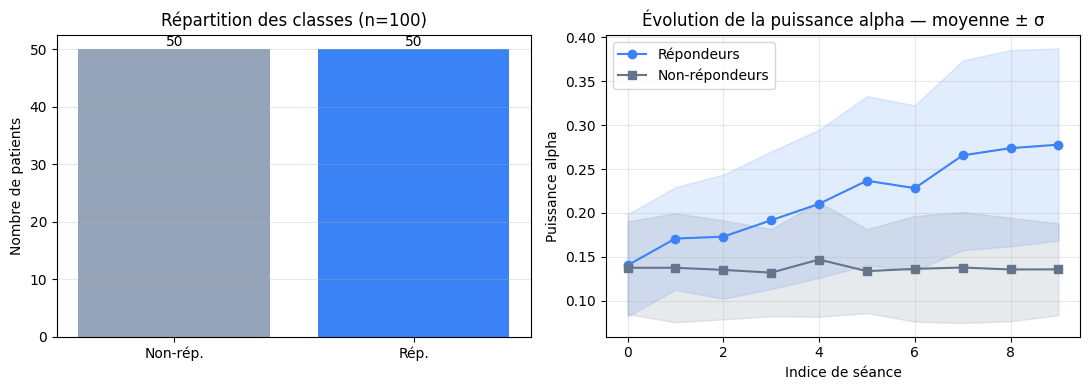

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

n_resp = int(y.sum()); n_non = len(y) - n_resp
axes[0].bar(["Non-rép.", "Rép."], [n_non, n_resp], color=["#94a3b8", "#3b82f6"])
for i, v in enumerate([n_non, n_resp]):
    axes[0].text(i, v + 0.5, str(v), ha="center")
axes[0].set_ylabel("Nombre de patients")
axes[0].set_title("Répartition des classes (n=100)")
axes[0].grid(axis="y", alpha=0.3)

def alpha_power(sig, fs):
    freqs, psd = welch(sig, fs=fs, nperseg=sig.shape[-1], axis=-1)
    return psd[..., (freqs >= 8) & (freqs <= 13)].mean(axis=-1)

alpha_per_s = np.stack([alpha_power(ds.signals[:, s, :], ds.fs) for s in range(ds.signals.shape[1])], axis=1)
sessions = np.arange(ds.signals.shape[1])
axes[1].plot(sessions, alpha_per_s[y == 1].mean(0), marker="o", color="#3b82f6", label="Répondeurs")
axes[1].fill_between(sessions, alpha_per_s[y == 1].mean(0) - alpha_per_s[y == 1].std(0),
                     alpha_per_s[y == 1].mean(0) + alpha_per_s[y == 1].std(0), alpha=0.15, color="#3b82f6")
axes[1].plot(sessions, alpha_per_s[y == 0].mean(0), marker="s", color="#64748b", label="Non-répondeurs")
axes[1].fill_between(sessions, alpha_per_s[y == 0].mean(0) - alpha_per_s[y == 0].std(0),
                     alpha_per_s[y == 0].mean(0) + alpha_per_s[y == 0].std(0), alpha=0.15, color="#64748b")
axes[1].set_xlabel("Indice de séance"); axes[1].set_ylabel("Puissance alpha")
axes[1].set_title("Évolution de la puissance alpha — moyenne ± σ")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Validation croisée patient-wise (5 folds)

In [3]:
lstm_cfg = LSTMConfig(input_size=X.shape[-1], hidden_sizes=(128, 64), dropout=0.3)
train_cfg = TrainConfig(epochs=40, batch_size=8, lr=3e-3, early_stopping_patience=6, seed=0)
cv = cross_validate(X, y, groups=groups, lstm_cfg=lstm_cfg, train_cfg=train_cfg, n_splits=5)
summary = cv.summary()
for k, v in summary.items():
    print(f"  {k:18s} {v:.3f}")

  accuracy_mean      0.980
  accuracy_std       0.040
  auc_mean           0.992
  auc_std            0.016
  f1_mean            0.978
  f1_std             0.044


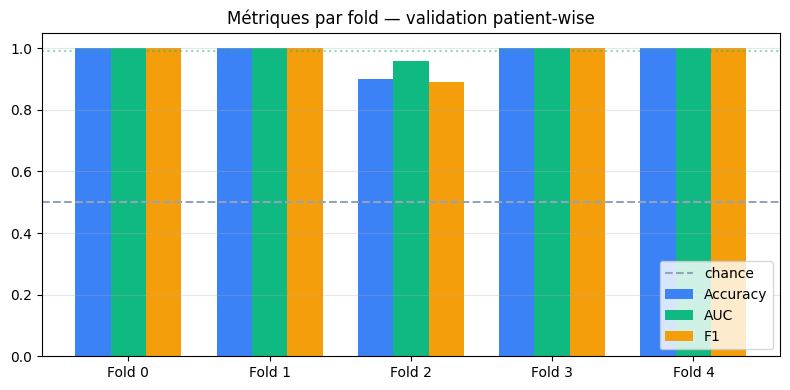

In [4]:
metrics = np.array([[f.accuracy, f.auc, f.f1] for f in cv.folds])
labels = [f"Fold {f.fold}" for f in cv.folds]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.25, metrics[:, 0], 0.25, label="Accuracy", color="#3b82f6")
ax.bar(x,        metrics[:, 1], 0.25, label="AUC",      color="#10b981")
ax.bar(x + 0.25, metrics[:, 2], 0.25, label="F1",       color="#f59e0b")
ax.axhline(0.5, color="#94a3b8", ls="--", label="chance")
ax.axhline(summary["auc_mean"], color="#10b981", ls=":", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05)
ax.set_title("Métriques par fold — validation patient-wise")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Diagnostics du modèle — courbe ROC, matrice de confusion, distribution des probabilités

Probabilités assemblées à partir des prédictions de chaque fold sur ses patients en validation (out-of-fold), donc sans fuite.

In [5]:
# Re-collecte les out-of-fold predictions
oof_proba = np.zeros(len(y))
from src.models.lstm import ResponseLSTM
from src.models.train import train_one_fold, _to_tensor
from sklearn.model_selection import GroupKFold

for fold_idx, (tr_idx, va_idx) in enumerate(GroupKFold(n_splits=5).split(X, y, groups=groups)):
    model = ResponseLSTM(LSTMConfig(input_size=X.shape[-1], hidden_sizes=(128, 64), dropout=0.3))
    train_one_fold(
        model,
        X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
        TrainConfig(epochs=40, batch_size=8, lr=3e-3, early_stopping_patience=6, seed=fold_idx),
    )
    with torch.no_grad():
        oof_proba[va_idx] = torch.sigmoid(model(_to_tensor(X[va_idx]))).numpy()

oof_pred = (oof_proba >= 0.5).astype(int)
print("OOF accuracy:", (oof_pred == y.astype(int)).mean())

OOF accuracy: 0.98


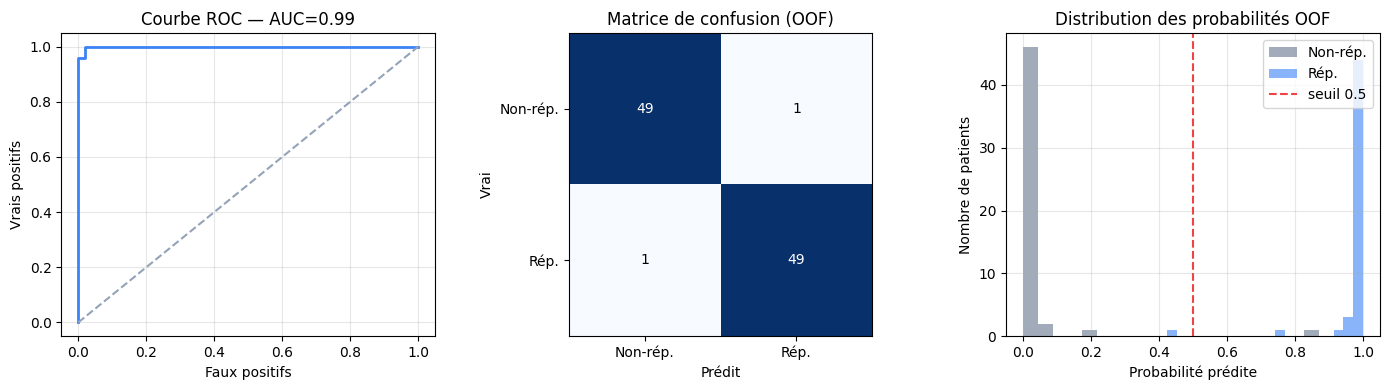

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fpr, tpr, _ = roc_curve(y.astype(int), oof_proba)
axes[0].plot(fpr, tpr, color="#3b82f6", lw=2)
axes[0].plot([0, 1], [0, 1], "--", color="#94a3b8")
axes[0].set_xlabel("Faux positifs"); axes[0].set_ylabel("Vrais positifs")
axes[0].set_title(f"Courbe ROC — AUC={summary['auc_mean']:.2f}"); axes[0].grid(alpha=0.3)

cm = confusion_matrix(y.astype(int), oof_pred)
im = axes[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Non-rép.", "Rép."])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Non-rép.", "Rép."])
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Vrai")
axes[1].set_title("Matrice de confusion (OOF)")

axes[2].hist(oof_proba[y == 0], bins=20, alpha=0.6, color="#64748b", label="Non-rép.")
axes[2].hist(oof_proba[y == 1], bins=20, alpha=0.6, color="#3b82f6", label="Rép.")
axes[2].axvline(0.5, color="#ef4444", ls="--", label="seuil 0.5")
axes[2].set_xlabel("Probabilité prédite"); axes[2].set_ylabel("Nombre de patients")
axes[2].set_title("Distribution des probabilités OOF")
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Importance des features (analyse univariée rapide)

Quel feature par séance est le plus discriminant entre les deux groupes ? Mesure : différence standardisée des moyennes (Cohen's d) sur la dernière séance.

C:\Users\naim_\AppData\Local\Temp\ipykernel_19476\1688717478.py:2: RuntimeWarning: invalid value encountered in divide
  d = (last[y == 1].mean(0) - last[y == 0].mean(0)) / np.sqrt(0.5 * (last[y == 1].var(0) + last[y == 0].var(0)))


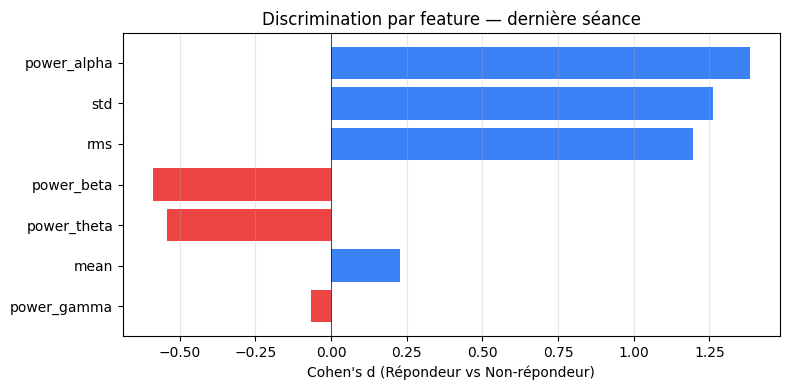

In [7]:
last = X[:, -1, :]  # dernière séance, features standardisés par patient
d = (last[y == 1].mean(0) - last[y == 0].mean(0)) / np.sqrt(0.5 * (last[y == 1].var(0) + last[y == 0].var(0)))
feature_names = list(pre.feature_names)
order = np.argsort(np.abs(d))[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#3b82f6" if d[i] > 0 else "#ef4444" for i in order]
ax.barh([feature_names[i] for i in order][::-1], [d[i] for i in order][::-1], color=colors[::-1])
ax.set_xlabel("Cohen's d (Répondeur vs Non-répondeur)")
ax.set_title("Discrimination par feature — dernière séance")
ax.axvline(0, color="#000", lw=0.5); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusion

- Le pipeline (simulateur → prétraitement → LSTM → CV patient-wise) fonctionne de bout en bout.
- Sur les données simulées, l'AUC dépasse largement 0.9 — chiffre **artificiellement élevé** car le simulateur injecte un biomarqueur (augmentation de la puissance alpha chez les répondeurs).
- Sur données réelles EEG/fNIRS, le chiffre attendu est nettement plus bas (0.6–0.75 dans la littérature rTMS).
- Le feature le plus discriminant est cohérent avec l'effet injecté (puissance alpha), ce qui valide que le modèle a appris la bonne chose.

Les figures de cette notebook sont prêtes à être incluses dans le rapport PFE.